In [ ]:
#imp :

# Use pretrained model in that .

In [ ]:
#T.L Defination - Transfer Learning is a technique where a model trained on one task is reused and fine-tuned for a related
#       task to improve performance and reduce training time .

In [ ]:
#We can use only Models who are free for us :

In [ ]:
# S : Get image fro mtransfer learning :

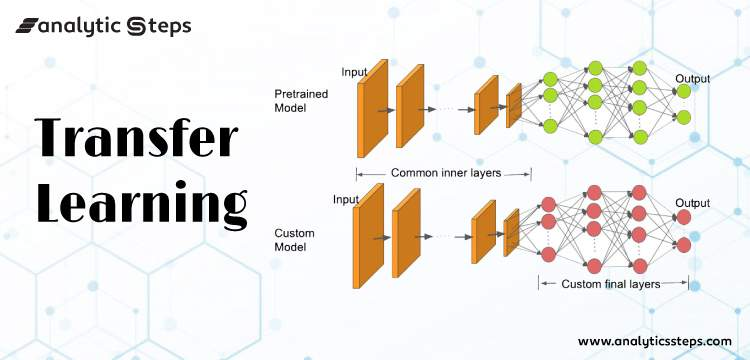![image.png]

In [ ]:
# imp- in TL we have to use dense layers our own but con2d we can use alredytrained model 

# Caste Study -5 : Potato Diseas Prediction With trasfer Learning

In [ ]:
# VGG 
# VGG16 ,19
# by visual geometry group
# very deep network
# VGG16 >> 13 Convolution layers ,3 Fully Connected layers(Dense) >> image size 224,224,3
# VGG19 >> 16 Convolution layers ,3 Fully Connected layers(Dense) >> image size 224,224,3


In [ ]:
# Step 1 - Read  imges 

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras 
import cv2
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from keras import Sequential
from pathlib import Path

In [ ]:
path=r'.\PlantVillage'

In [ ]:
#to check how many paths we just use glob method to only check :
win_path=Path(path)

In [ ]:
folders=list(win_path.glob('*'))

In [ ]:
folders    # now check all folders paths of images

[WindowsPath('PlantVillage/Potato___Early_blight'),
 WindowsPath('PlantVillage/Potato___healthy'),
 WindowsPath('PlantVillage/Potato___Late_blight')]

In [ ]:
# to check all images paths catg. wise :

all_imges=list(win_path.glob('*/*.jpg'))

In [ ]:
all_imges

[WindowsPath('PlantVillage/Potato___Early_blight/001187a0-57ab-4329-baff-e7246a9edeb0___RS_Early.B 8178.JPG'),
 WindowsPath('PlantVillage/Potato___Early_blight/002a55fb-7a3d-4a3a-aca8-ce2d5ebc6925___RS_Early.B 8170.JPG'),
 WindowsPath('PlantVillage/Potato___Early_blight/009c8c31-f22d-4ffd-8f16-189c6f06c577___RS_Early.B 7885.JPG'),
 WindowsPath('PlantVillage/Potato___Early_blight/00d8f10f-5038-4e0f-bb58-0b885ddc0cc5___RS_Early.B 8722.JPG'),
 WindowsPath('PlantVillage/Potato___Early_blight/0182e991-97f0-4805-a1f7-6e1b4306d518___RS_Early.B 7015.JPG'),
 WindowsPath('PlantVillage/Potato___Early_blight/02578b86-b234-4ac0-9bc3-691b5610e2bf___RS_Early.B 7562.JPG'),
 WindowsPath('PlantVillage/Potato___Early_blight/0267d4ca-522e-4ca0-b1a2-ce925e5b54a2___RS_Early.B 7020.JPG'),
 WindowsPath('PlantVillage/Potato___Early_blight/028f9b73-142f-499a-9c7b-d7c1ed5e5506___RS_Early.B 8546.JPG'),
 WindowsPath('PlantVillage/Potato___Early_blight/034959c1-f1e8-4a79-a6d5-3c1d14efa2f3___RS_Early.B 7136.JPG'),
 

In [ ]:
# check count of all_imges paths :

len(all_imges)

2754

In [ ]:
# Step 2 - Create imageDataGenerator  Object :

In [ ]:
datagen = ImageDataGenerator(
                             rescale=1./255,   # if u enter float no. instead of intiger value then it use less memory issue 
                             validation_split=0.2,          # 80% train , and 20% use for validation
                             rotation_range=20,           
                             zoom_range=0.2,
                             horizontal_flip=True
                           )

In [19]:
train_data= datagen.flow_from_directory(path,                        # flow_from_diretory : use for read and get images from path
                            target_size=(224,224),
                            batch_size=32,
                            shuffle=True,
                            class_mode='categorical',
                            subset='training' )

Found 2204 images belonging to 3 classes.


In [20]:
test_data= datagen.flow_from_directory(path,
                            target_size=(224,224),
                            batch_size=32,
                            shuffle=False,
                            class_mode='categorical',
                            subset='validation' )

Found 550 images belonging to 3 classes.


In [21]:
1721+429

2150

In [22]:
for i,j in train_data:       # it wil extract 32 batch wise imges pth in i and labels j, and labels are one hot encoded. 
    print(i.shape,j.shape)
    break

(32, 224, 224, 3) (32, 3)


In [23]:
# Step -3 image check and class name classification :

In [24]:
# check class and its name in dic. form :

class_dict=train_data.class_indices

In [25]:
class_dict

{'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}

In [26]:
# for get class names in lists:
class_names=list(train_data.class_indices.keys())

In [27]:
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

Potato___Early_blight


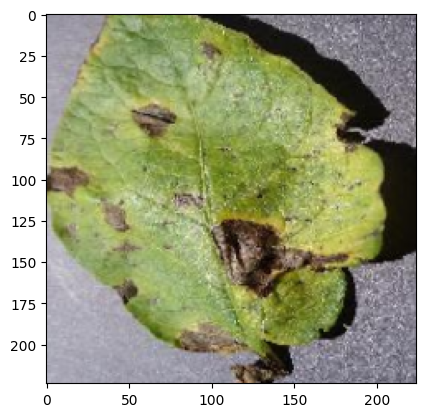

In [28]:
# lets check random image show and label and index check of that image and category :

for i,j in train_data:
    plt.imshow(i[0])
    print(class_names[np.argmax(j[0])])
    break

In [29]:
# Step -4 Check Data balance :

In [30]:
s1=pd.Series(train_data.classes)
s1.value_counts()

0    800
1    800
2    604
Name: count, dtype: int64

In [31]:
# so the data set is balance

In [32]:
# step -4 Model Training : 

In [33]:
from tensorflow.keras.applications import VGG16,VGG19

In [34]:
base_model = VGG19(
    weights='imagenet',        # imagenet it is  dataset name -whomw it model is trained
    include_top=False,         # We have to our  own dense layer so we use include_top = false to drop models dense layer
    input_shape=(224,224,3)
)

In [35]:
#VGG19 = 16 convolution layer , and 3 dense layers

In [36]:
# 16 layers >> Freeze  - because we have using 16 convlution layers as it  is so it wil not be trained again ,we trained only dense layer
# Why freeze
# We only want to train our new classification layers(fully connected layers)
# We don’t want to re-train the pre-trained knowledge


In [37]:
# let freeze the convolution layer for not train again and use  dense to train require only :

In [38]:
for layer in base_model.layers:
    layer.trainable=False

In [39]:
import keras
from keras import Sequential

In [ ]:
final_model = keras.Sequential([
    base_model,
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(64,activation='relu'),
    Dropout(0.3),
    Dense(3,activation='softmax')
])

final_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

final_model.fit(train_data,validation_data=(test_data),epochs= 2)
    

Epoch 1/4
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1158s/step - accuracy: 0.4773 - loss: 1.7583   

In [ ]:
# Step - 5 Check test accuracy :

In [ ]:
final_model.evaluate(test_data)

In [ ]:
# Step - 6 Predict the model :

In [ ]:
y_pred= final_model.predict(test_data)
y_pred1=[ np.argmax(i) for i in y_pred]

In [ ]:
y_test=test_data.classes

In [ ]:
# step -7 Check metrics :

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [ ]:
print(confusion_matrix(y_test,y_pred1))

In [ ]:
print(classification_report(y_test,y_pred1))

In [ ]:
# Step - 8 Save model :

In [ ]:
final_model.save('VGG19_potato_disease.keras')

In [ ]:
# Step -9  we can predict New image using model : 

In [ ]:
from tensorflow.keras.preprocessing.image import load_img,img_to_array

In [ ]:
path=r'C:\Users\admin\Desktop\potato_plant_img.jfif'

In [ ]:
img1=load_img(path,target_size=(224,224))

In [ ]:
img1

In [ ]:
# now convert img to array ,scale and 4D for use trained maodel :

In [ ]:
img2=img_to_array(img1)
img3=img2/255.0
img4= np.expand_dims(img3,axis=0)   # use for convert in ( 1,256,256,3 ) for single img

In [ ]:
# now check shape :

img4.shape

In [ ]:
#Now predict that img using model :

In [ ]:
class_names[np.argmax(final_model.predict(img4))]  # it gives probablity in 3 cate. becuse  use class name and argmax to give who is best match and its name 

In [ ]:
# Step - 10  Deployment :  ( need - vs code,git, github,python 3.10 version )

# Steps For Deployment :
1. Create Project Folder. (itvproject)
2. Create New Repository. ( repository name - CNN potato_desease_pred )
3. Create GitHUb clone. (>>Itvproject >> right click >> gitbash command >> github clone url )
4. Open VS Code for clone folder.
5. install extentions. (>> python, jupyter, code runner.)
6. Copy Python Path to environment veriables . 
 ( >> goto C drive >> show hidden items and get  pythons 310 path >>  C:\Users\admin\AppData\Local\Programs\Python\Python310, and                         Scripts path >> C:\Users\admin\AppData\Local\Programs\Python\Python310\Scripts and copy and pest in envormental verables by searching.
7. Create Vertual Environment . ( We can use by - VS-Code terminal and Anaconda prompt ) >> Use vs-code terminal-python -m venv environmnet project neme any , >> eg project_environment or py -3.10 -m venv venv_3_10 for we use vs version 3.10. and then >> .\pyenv\Scripts\activate command use .
8. Step-8 create app.py and new1.ipynb 